## Deep Reinforcement Learning - Assignment 1

| Field | Details |
|---|---|
| **Group Name** | Team 7 |
| **Assignment** | Autonomous Drone Rescue Using Dynamic Programming |
| **Course** | Deep Reinforcement Learning |
| **Date** | 22-May-2026 |

---

### Part 2 - Autonomous Drone Rescue Using Dynamic Programming

# Introduction

This assignment implements an Autonomous Drone Rescue Environment
using Dynamic Programming techniques. The environment models
battery-aware navigation, rescue targets, charging stations,
danger zones, blocked cells, and stochastic weather conditions.

The objective is to compute an optimal rescue policy using
Value Iteration.

In [22]:
# =========================================================
# Environment Setup
# =========================================================

required_packages = [
    "numpy",
    "matplotlib",
    "pandas",
    "seaborn"
]

for package in required_packages:
    !pip install -q {package}

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import random
import time

from collections import defaultdict
from itertools import product
import socket
import platform
import os
from datetime import datetime

In [16]:
# =========================================================
# Assignment Metadata
# =========================================================

GROUP_ID = 7

print("Execution Timestamp :", datetime.now())
print("Group ID            :", GROUP_ID)

random.seed(GROUP_ID)
np.random.seed(GROUP_ID)

print("========================================")
print(" Assignment Execution Information")
print("========================================")

# Current Timestamp
current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Timestamp           : {current_time}")

# Machine / VM Information
print(f"Machine Name        : {socket.gethostname()}")

# Platform Information
print(f"Platform            : {platform.system()} {platform.release()}")

# Processor Information
print(f"Processor           : {platform.processor()}")

# User Information
print(f"User                : {os.getenv('USER') or os.getenv('USERNAME')}")

print("========================================")

Execution Timestamp : 2026-05-27 14:24:56.230858
Group ID            : 7
 Assignment Execution Information
Timestamp           : 2026-05-27 14:24:56
Machine Name        : Ram
Platform            : Windows 11
Processor           : Intel64 Family 6 Model 198 Stepping 2, GenuineIntel
User                : mrdud


In [3]:
# =========================================================
# Grid World
# =========================================================

class GridWorld:
    
    # =====================================================
    # Constructor
    # =====================================================
    
    def __init__(self,group_id):
        """
        Initializes dynamic grid world.
        """
        self.group_id = group_id
        self.configure_environment()
        self.generate_grid()
        self.extract_entities()

    # =====================================================
    # Environment Configuration
    # =====================================================

    def configure_environment(self):
        """
        Configures environment based on group ID.
        """
        last_digit = self.group_id % 10
        # -------------------------------------------------
        # Grid Size
        # -------------------------------------------------
        if last_digit <= 4:
            self.grid_size = 5
            self.total_rescue_targets = 2
            self.total_charging_stations = 1
            self.total_danger_zones = 3
            self.total_blocked_cells = 2
            self.wind_probability = 0.20
            self.max_steps = 50
        else:
            self.grid_size = 6
            self.total_rescue_targets = 3
            self.total_charging_stations = 2
            self.total_danger_zones = 4
            self.total_blocked_cells = 3
            self.wind_probability = 0.30
            self.max_steps = 75
            
        # -------------------------------------------------
        # Battery Capacity
        # -------------------------------------------------
        if last_digit % 2 == 0:
            self.max_battery = 10
        else:
            self.max_battery = 15
        self.start_position = (0, 0)

    # =====================================================
    # Dynamic Grid Generation
    # =====================================================

    def generate_grid(self):
        """
        Dynamically generates grid world.
        """
        self.grid = np.full((self.grid_size,self.grid_size),"F")
        self.grid[self.start_position] = "S"
        occupied_positions = {self.start_position}
        def place_entities(symbol, count):
            placed_positions = []
            while len(placed_positions) < count:
                row = np.random.randint(0,self.grid_size)
                col = np.random.randint(0,self.grid_size)
                position = (row, col)
                if position in occupied_positions:
                    continue
                self.grid[position] = symbol
                occupied_positions.add(position)
                placed_positions.append(position)
            return placed_positions
        place_entities("R",self.total_rescue_targets)
        place_entities("C",self.total_charging_stations)
        place_entities("D",self.total_danger_zones)
        place_entities("X",self.total_blocked_cells)
        place_entities("W",2)

    # =====================================================
    # Entity Extraction
    # =====================================================

    def extract_entities(self):
        """
        Extracts environment entities from grid.
        """
        self.rescue_positions = []
        self.charging_stations = []
        self.danger_zones = []
        self.blocked_cells = []
        self.wind_zones = []
        for row in range(self.grid_size):
            for col in range(self.grid_size):
                position = (row, col)
                cell = self.grid[position]
                if cell == "R":
                    self.rescue_positions.append(position)
                elif cell == "C":
                    self.charging_stations.append(position)
                elif cell == "D":
                    self.danger_zones.append(position)
                elif cell == "X":
                    self.blocked_cells.append(position)
                elif cell == "W":
                    self.wind_zones.append(position)

    # =====================================================
    # Grid Rendering
    # =====================================================

    def render(self):
        """
        Displays grid world.
        """
        print("\nGrid World\n")
        for row in self.grid:
            print("  ".join(row))

In [4]:
# =========================================================
# Initialize Grid World
# =========================================================

grid_world = GridWorld(
    group_id=GROUP_ID
)

grid_world.render()


Grid World

S  R  F  D  C  X
F  F  F  W  X  F
X  F  C  D  F  F
W  F  F  R  F  F
F  R  F  F  D  F
D  F  F  F  F  F


In [5]:
# =========================================================
# Drone Agent
# =========================================================

class Drone:

    ACTIONS = [
        "UP",
        "DOWN",
        "LEFT",
        "RIGHT",
        "HOVER"
    ]
    
    ACTION_DELTAS = {
        "UP": (-1, 0),
        "DOWN": (1, 0),
        "LEFT": (0, -1),
        "RIGHT": (0, 1),
        "HOVER": (0, 0)
    }
    # =====================================================
    # Constructor
    # =====================================================
    def __init__(self,start_position,max_battery,rescue_positions):
        """
        Initializes drone agent.
        """
        self.start_position = start_position
        self.max_battery = max_battery
        self.rescue_positions = rescue_positions
        self.reset()
        
    # =====================================================
    # Reset Drone State
    # =====================================================

    def reset(self):
        """
        Resets drone state.
        """
        self.position = self.start_position
        self.battery_level = self.max_battery
        self.rescued_targets = set()
        self.steps_taken = 0
    
    # =====================================================
    # State Representation
    # =====================================================

    def get_state(self):
        """
        Returns drone state representation.
        """
        rescue_status = tuple(position in self.rescued_targets for position in self.rescue_positions)
        return (self.position,self.battery_level,rescue_status)
        
    # =====================================================
    # Battery Update Logic
    # =====================================================
    def update_battery(self,action,cell_type,current_battery):
        """
        Updates battery level based on:
        - action
        - current cell type
        """
        # -------------------------------------------------
        # Hover On Charging Station
        # -------------------------------------------------
        if (action == "HOVER" and cell_type == "C"):
            updated_battery = min(current_battery + 2,self.max_battery)
            return updated_battery
        # -------------------------------------------------
        # Enter Charging Station
        # -------------------------------------------------
        if (action != "HOVER" and cell_type == "C"):
            return self.max_battery

        # -------------------------------------------------
        # Regular Battery Consumption
        # -------------------------------------------------
        updated_battery = max(current_battery - 1,0)
        return updated_battery
        
   
    # =====================================================
    # Drone Movement
    # =====================================================

    def move(self,new_position):
        """
        Updates drone position.
        """
        self.position = new_position
        self.steps_taken += 1

    # =====================================================
    # Rescue Target Completion
    # =====================================================

    def rescue_target(self,target_position):
        """
        Marks rescue target as completed.
        """
        self.rescued_targets.add(target_position)

    # =====================================================
    # Compute Next Position
    # =====================================================
    def compute_next_position(self,current_position,action):
        """
        Computes next drone position.
        """
        current_row, current_col = (current_position)
        delta_row, delta_col = (self.ACTION_DELTAS[action])
        new_position = (current_row + delta_row,current_col + delta_col)
        return new_position

    # =====================================================
    # Update Rescue Status
    # =====================================================
    def update_rescue_status(self,new_position,rescue_status):
        """
        Updates rescue completion status.
        """
        updated_rescue_status = list(rescue_status)
        for index, rescue_position in enumerate(self.rescue_positions):
            # Rescue target reached
            if (new_position == rescue_position and not rescue_status[index]):
                updated_rescue_status[index] = True
        return tuple(updated_rescue_status)

# Markov Decision Process Formulation

State Space:
s = (position, battery_level, rescue_status)

Action Space:
A = {UP, DOWN, LEFT, RIGHT}

Reward Function:
+20  Rescue
-10  Danger Zone
-20  Battery Exhausted
+5   Charging Station
-1   Regular Movement

Transition Dynamics:
The environment includes stochastic wind effects causing
probabilistic movement deviations.

In [6]:
# =========================================================
# Drone Rescue Environment
# =========================================================

class DroneRescueEnvironment:

    # =====================================================
    # Constructor
    # =====================================================
    def __init__(self,grid_world,drone):
        """
        Initializes drone rescue environment.
        """
        self.grid_world = grid_world
        self.drone = drone
        self.grid = grid_world.grid
        self.grid_size = (grid_world.grid_size)
        self.max_steps = (grid_world.max_steps)
        self.wind_probability = (grid_world.wind_probability)
        self.reset()
    
    # =====================================================
    # Environment Reset
    # =====================================================
    
    def reset(self):
        """
        Resets environment state.
        """
        self.drone.reset()
        self.done = False
        return self.drone.get_state()
    
    # =====================================================
    # Position Validation
    # =====================================================

    def is_valid_position(self,row,col):
        """
        Checks whether position is valid.
        """
        # Boundary validation
        if row < 0 or row >= self.grid_size:
            return False
        if col < 0 or col >= self.grid_size:
            return False
        # Blocked cell validation
        if (row, col) in self.grid_world.blocked_cells:
            return False
        return True
        
    # =====================================================
    # Wind Disturbance
    # =====================================================

    def apply_wind_disturbance(self,current_position,action):
        """
        Applies stochastic wind disturbance.
        """
        # Hover unaffected
        if action == "HOVER":
            return action
        # Wind affects only wind zones
        if current_position not in self.grid_world.wind_zones:
            return action
        random_value = np.random.random()
        # Wind event occurs
        if random_value < self.wind_probability:
            movement_actions = ["UP","DOWN","LEFT","RIGHT"]
            disturbed_action = random.choice(movement_actions)
            return disturbed_action
        return action

    # =====================================================
    # Pure Transition Function
    # =====================================================

    def transition(self,state,action, apply_wind=True):
        """
            Simulates transition without mutating
            actual environment state.
            IMPORTANT:
                steps_taken is REMOVED from state representation
                to avoid state-space explosion.
            State Format:
            (
                position,
                battery_level,
                rescue_status
            )
        """
        position, battery_level, rescue_status = state
        # -------------------------------------------------
        # Wind Disturbance
        # -------------------------------------------------
        if apply_wind:
            action = self.apply_wind_disturbance(position,action)
        # -------------------------------------------------
        # Movement
        # -------------------------------------------------
        new_position = self.drone.compute_next_position(position, action)
        new_row, new_col = new_position
        if not self.is_valid_position(new_row,new_col):
            new_position = position
        cell_type = self.grid_world.grid[new_position]
        # -------------------------------------------------
        # Battery Consumption
        # -------------------------------------------------
        new_battery = self.drone.update_battery(action,cell_type,battery_level)
        # -------------------------------------------------
        # Rescue Status Update
        # -------------------------------------------------
        updated_rescue_status = (self.drone.update_rescue_status(new_position,rescue_status))
        # -------------------------------------------------
        # Reward Computation
        # -------------------------------------------------
        reward = self.compute_reward(new_position,new_battery,rescue_status)
        next_state = (new_position,new_battery,updated_rescue_status)
        done = self.check_termination(new_battery,updated_rescue_status)
        return (next_state,reward,done)

    # =====================================================
    # Reward Function
    # =====================================================
    def compute_reward(self,new_position,new_battery,rescue_status):
        """
        Computes transition reward.
        """
        # -------------------------------------------------
        # Regular Movement
        # -------------------------------------------------
        reward = -1
        # -------------------------------------------------
        # Danger Zone
        # -------------------------------------------------
        if (new_position in self.grid_world.danger_zones):
            reward -= 10
        # -------------------------------------------------
        # Charging Station
        # -------------------------------------------------
        if (new_position in self.grid_world.charging_stations):
            reward += 5
        # -------------------------------------------------
        # Rescue Target
        # -------------------------------------------------
        for index, rescue_position in enumerate(self.grid_world.rescue_positions):
            if (new_position == rescue_position and not rescue_status[index]):
                reward += 20
        # -------------------------------------------------
        # Battery Exhausted
        # -------------------------------------------------
        if new_battery <= 0:
            reward -= 20
        return reward

    # =====================================================
    # Episode Termination
    # =====================================================
    def check_termination(self,battery_level,rescue_status):
        """
        Checks whether episode terminates.
        """
        # Battery exhausted
        if battery_level <= 0:
            return True
        # All rescues completed
        if all(rescue_status):
            return True
        return False
        
    # =====================================================
    # Environment Step
    # =====================================================
    def step(self,action):
        """
        Executes one environment transition.
        """
        if self.done:
            raise Exception("Episode already terminated.")
        self.drone.steps_taken +=1
        # -------------------------------------------------
        # Current Runtime State
        # -------------------------------------------------
        current_state = (self.drone.position,self.drone.battery_level,tuple(position in self.drone.rescued_targets 
                                                                              for position in self.grid_world.rescue_positions))
        # -------------------------------------------------
        # Simulate Transition
        # -------------------------------------------------
        next_state, reward, done = (self.transition(current_state,action))
        # -------------------------------------------------
        # Extract Next State
        # -------------------------------------------------
        (
            next_position,
            next_battery,
            rescue_status
        ) = next_state
        # -------------------------------------------------
        # Apply Runtime Updates
        # -------------------------------------------------
        self.drone.move(next_position)
        self.drone.battery_level = (next_battery)
        
        # -------------------------------------------------
        # Update Rescued Targets
        # -------------------------------------------------
        self.drone.rescued_targets.clear()
        for index, rescue_completed in enumerate(rescue_status):
            if rescue_completed:
                self.drone.rescued_targets.add(self.grid_world.rescue_positions[index])
        # -------------------------------------------------
        # Remove Rescued Targets From Grid
        # -------------------------------------------------
        for rescued_position in (self.drone.rescued_targets):
            self.grid[rescued_position] = "F"
        # -------------------------------------------------
        # Environment Done
        # -------------------------------------------------
        if self.drone.steps_taken >= self.max_steps:
            done = True
        self.done = done
        return (next_state,reward,done)

    # =====================================================
    # Environment Rendering
    # =====================================================

    def render(self):
        """
        Renders current environment state.
        """
        rendered_grid = np.copy(self.grid)
        drone_row, drone_col = (self.drone.position)
        original_cell = rendered_grid[drone_row,drone_col]
        rendered_grid[drone_row,drone_col] = "A"
        print("\nDrone Rescue Environment\n")
        for row in rendered_grid:
            print("  ".join(row))
        print("\nBattery :",self.drone.battery_level)
        print("Rescued Targets :",len(self.drone.rescued_targets))
        print("Steps Taken :",self.drone.steps_taken)

In [7]:
# =========================================================
# Initialize Environment
# =========================================================

drone = Drone(
    start_position=grid_world.start_position,
    max_battery=grid_world.max_battery,
    rescue_positions= grid_world.rescue_positions
)

environment =DroneRescueEnvironment(
    grid_world=grid_world,
    drone=drone
)

environment.render()


Drone Rescue Environment

A  R  F  D  C  X
F  F  F  W  X  F
X  F  C  D  F  F
W  F  F  R  F  F
F  R  F  F  D  F
D  F  F  F  F  F

Battery : 15
Rescued Targets : 0
Steps Taken : 0


In [8]:
# =========================================================
# Example Environment Interaction
# =========================================================

next_state, reward, done = environment.step(
    "RIGHT"
)

print("\nNext State :", next_state)

print("Reward :", reward)

print("Done :", done)

environment.render()


Next State : ((0, 1), 14, (True, False, False))
Reward : 19
Done : False

Drone Rescue Environment

S  A  F  D  C  X
F  F  F  W  X  F
X  F  C  D  F  F
W  F  F  R  F  F
F  R  F  F  D  F
D  F  F  F  F  F

Battery : 14
Rescued Targets : 1
Steps Taken : 2


# Dynamic Programming Solution

The environment is solved using the Value Iteration algorithm, a classical Dynamic Programming method used for solving finite Markov Decision Processes (MDPs). The algorithm iteratively updates the value of each reachable state using the Bellman Optimality Equation until convergence is achieved.

The objective of Value Iteration is to compute:
- Optimal Value Function: V*(s)
- Optimal Policy: π*(s)

The implementation uses:
- Discount Factor (γ) = 0.95
- Convergence Threshold (θ) = 10^-3

The algorithm evaluates all reachable states generated from the environment state representation and computes the optimal rescue strategy for the autonomous drone.

In [12]:
# =========================================================
# Value Iteration Agent
# =========================================================

class ValueIterationAgent:

    def __init__(self,environment,gamma=0.95,theta=1e-3):
        """
        Initializes Value Iteration solver.
        """
        self.environment = environment
        self.gamma = gamma
        self.theta = theta
        self.states = []
        self.value_function = {}
        self.policy = {}
        self.iterations = 0
        self.final_delta = None
        self.runtime = None
        print("Value Interation Agent Initialized")
        
    # =====================================================
    # Reachable State Enumeration
    # =====================================================

    def enumerate_states(self):
        """
        Enumerates all reachable states.
        """
        reachable_positions = []
        # -------------------------------------------------
        # Valid Positions
        # -------------------------------------------------
        for row in range(self.environment.grid_size):
            for col in range(self.environment.grid_size):
                position = (row, col)
                if (position not in self.environment.grid_world.blocked_cells):
                    reachable_positions.append(position)
        print("Reachable Positions Computed ", len(reachable_positions))
        # -------------------------------------------------
        # Rescue Status Combinations
        # -------------------------------------------------
        total_rescue_targets = len(self.environment.grid_world.rescue_positions)
        rescue_combinations = []
        for value in range(2 ** total_rescue_targets):
            binary_representation = format(value,f'0{total_rescue_targets}b')
            rescue_status = tuple(bit == '1' for bit in binary_representation)
            rescue_combinations.append(rescue_status)
        print("Rescue Combinations Computed")
        # -------------------------------------------------
        # Full State Enumeration
        # -------------------------------------------------
        for position in reachable_positions:
            for battery_level in range(self.environment.drone.max_battery + 1):
                for rescue_status in rescue_combinations:
                        state = (position,battery_level,rescue_status)
                        self.states.append(state)
                        self.value_function[state] = 0.0
        print("Total Reachable States :",len(self.states))

    # =====================================================
    # Terminal State Check
    # =====================================================

    def is_terminal_state(self,state):
        """
        Checks whether state is terminal.
        """
        position, battery_level, rescue_status = state
        # Battery exhausted
        if battery_level <= 0:
            return True
        # All rescues completed
        if all(rescue_status):
            return True
        return False

    # =====================================================
    # Valid Actions
    # =====================================================

    def get_valid_actions(self,state):
        """
        Returns valid actions for given state.
        """
        position, _, _ = state
        valid_actions = []
        current_row, current_col = position
        for action, (delta_row, delta_col) in Drone.ACTION_DELTAS.items():
            # Hover always valid
            if action == "HOVER":
                valid_actions.append(action)
                continue
            new_row = current_row + delta_row
            new_col = current_col + delta_col
            # Boundary checks
            if (new_row < 0 or new_row >= self.environment.grid_size):
                continue
            if (new_col < 0 or new_col >= self.environment.grid_size):
                continue
            # Blocked cells
            if ((new_row, new_col) in self.environment.grid_world.blocked_cells):
                continue
            valid_actions.append(action)
        return valid_actions

    # =====================================================
    # Bellman Q-Value Computation
    # =====================================================

    def compute_q_value(self,state,action):
        """
        Computes Bellman Q-value.
        Wind disturbance was disabled during Value Iteration planning to ensure convergence stability of Bellman updates. 
        Wind stochasticity is still applied during actual environment execution through the step() function.
        """
        next_state, reward, done = (self.environment.transition(state,action, apply_wind=False))
        # Terminal next state
        if done:
            return reward
        q_value = (reward+self.gamma *self.value_function[next_state])
        return q_value

    # =====================================================
    # Value Iteration Algorithm
    # =====================================================
    
    def run_value_iteration(self, max_iterations=200):
        """
        Executes asynchronous Value Iteration.
        IMPORTANT:
            State should ONLY represent the environment state.
        Example:
            state = (x, y)
        Do NOT include:
            steps_taken
            iteration_count
            episode_step
        Otherwise state-space explosion occurs.
        """
        start_time = time.time()
        while True:
            delta = 0.0
            # -------------------------------------------------
            # Iterate Through All States
            # -------------------------------------------------
            for state in self.states:
                # Terminal state
                if self.is_terminal_state(state):
                    self.value_function[state] = 0
                    continue
                valid_actions = (self.get_valid_actions(state))
                if not valid_actions:
                    continue
                # Compute all Q-values
                q_values = []
                for action in valid_actions:
                    q_value = self.compute_q_value(state,action)
                    q_values.append(q_value)
                # Bellman Optimality Update
                if not q_values:
                    continue
                best_value = max(q_values)
               # print(f"State {state} | best Values : {best_value}")
                old_value = self.value_function[state]
                # ASYNCHRONOUS UPDATE
                self.value_function[state] = (best_value)
                # Track convergence delta
                delta = max(delta,abs(old_value - best_value))
            # -------------------------------------------------
            # Update Value Function
            # -------------------------------------------------
            # self.value_function.update(updated_values)
            self.iterations += 1
            if self.iterations >= max_iterations:
                print("\nMaximum iterations reached.")
                self.final_delta = delta
                break
            
            print(f"Iteration {self.iterations} | "f"Delta = {delta:.6f}")
            # -------------------------------------------------
            # Convergence Check
            # -------------------------------------------------
            if delta < self.theta:
                self.final_delta = delta
                break
        end_time = time.time()
        self.runtime = (end_time - start_time)
        print("\nValue Iteration Converged")
        print("Iterations :",self.iterations)
        print("Final Delta :",self.final_delta)
        print("Runtime :",round(self.runtime, 4),"seconds")

    # =====================================================
    # Optimal Policy Extraction
    # =====================================================

    def extract_policy(self):
        """
        Extracts optimal policy.
        """
        for state in self.states:
            # Terminal state
            if self.is_terminal_state(state):
                self.policy[state] = None
                continue
            valid_actions = (self.get_valid_actions(state))
            best_action = None
            best_q_value = float("-inf")
            for action in valid_actions:
                q_value = self.compute_q_value(state,action)
                if q_value > best_q_value:
                    best_q_value = q_value
                    best_action = action
            self.policy[state] = best_action
        print("\nOptimal Policy Extracted")

    # =====================================================
    # Policy Visualization
    # =====================================================

    def visualize_policy(self):
        """
        Displays optimal policy grid.
        """
        # -------------------------------------------------
        # Action Symbols
        # -------------------------------------------------
        action_symbols = {
            "UP": "↑",
            "DOWN": "↓",
            "LEFT": "←",
            "RIGHT": "→",
            "HOVER": "H"
        }
        # -------------------------------------------------
        # Create Visualization Grid
        # -------------------------------------------------
        policy_grid = np.full((self.environment.grid_size,self.environment.grid_size)," ")
        # -------------------------------------------------
        # Fill Static Environment Objects
        # -------------------------------------------------
        for row in range(self.environment.grid_size):
            for col in range(self.environment.grid_size):
                position = (row, col)
                # Blocked cells
                if (position in self.environment.grid_world.blocked_cells):
                    policy_grid[position] = "X"
                # Danger zones
                elif (position in self.environment.grid_world.danger_zones):
                    policy_grid[position] = "D"
                # Charging stations
                elif (position in self.environment.grid_world.charging_stations):
                    policy_grid[position] = "C"
                # Rescue targets
                elif (position in self.environment.grid_world.rescue_positions):
                    policy_grid[position] = "R"
        # -------------------------------------------------
        # Overlay Optimal Actions
        # -------------------------------------------------
        initial_rescue_status = tuple(False for _ in self.environment.grid_world.rescue_positions)
        for row in range(self.environment.grid_size):
            for col in range(self.environment.grid_size):
                position = (row, col)
                # Skip blocked cells
                if (position in self.environment.grid_world.blocked_cells):
                    continue
                # Representative state
                state = (position,self.environment.drone.max_battery,initial_rescue_status)
                # Policy exists
                if state in self.policy:
                    action = self.policy[state]
                    if action is not None:
                        policy_grid[position] = (action_symbols[action])
        # -------------------------------------------------
        # Start Position
        # -------------------------------------------------
        start_row, start_col = (self.environment.grid_world.start_position)
        policy_grid[start_row,start_col] = "S"
        # -------------------------------------------------
        # Display Policy Grid
        # -------------------------------------------------
        print("\nOptimal Policy Visualization\n")
        for row in policy_grid:
            print("  ".join(row))

    def visualize_value_function(self):
        """
            Visualizes V*(s) as heatmap
            for a fixed battery and rescue state.
        """
        # -------------------------------------------------
        # Fixed Slice Parameters
        # -------------------------------------------------
        battery_level = self.environment.drone.max_battery
        rescue_status = tuple(False for _ in self.environment.grid_world.rescue_positions)
        # -------------------------------------------------
        # Create Grid
        # -------------------------------------------------
        value_grid = np.full((self.environment.grid_size,self.environment.grid_size),np.nan)
        # -------------------------------------------------
        # Fill Values
        # -------------------------------------------------
        for row in range(self.environment.grid_size):
            for col in range(self.environment.grid_size):
                position = (row, col)
                # Skip blocked cells
                if position in self.environment.grid_world.blocked_cells:
                    continue
                state = (position,battery_level,rescue_status)
                value_grid[row, col] = (self.value_function.get(state, 0.0))
        # -------------------------------------------------
        # Plot Heatmap
        # -------------------------------------------------
        plt.figure(figsize=(8, 6))
        plt.imshow(value_grid)
        plt.colorbar(label="V*(s)")
        plt.title("Optimal State Value Heatmap")
        plt.xlabel("Column")
        plt.ylabel("Row")
        # -------------------------------------------------
        # Annotate Values
        # -------------------------------------------------
        for row in range(self.environment.grid_size):
            for col in range(self.environment.grid_size):
                if not np.isnan(value_grid[row, col]):
                    plt.text(col,row,f"{value_grid[row,col]:.1f}",ha="center",va="center")
        plt.show()

In [17]:
# =========================================================
# Initialize Value Iteration Agent
# =========================================================

value_agent = ValueIterationAgent(
    environment=environment, gamma=0.85
)

# =========================================================
# Enumerate States
# =========================================================

value_agent.enumerate_states()

# =========================================================
# Run Value Iteration
# =========================================================

value_agent.run_value_iteration()

Value Interation Agent Initialized
Reachable Positions Computed  33
Rescue Combinations Computed
Total Reachable States : 4224
Iteration 1 | Delta = 29.095875
Iteration 2 | Delta = 18.581494
Iteration 3 | Delta = 15.172500
Iteration 4 | Delta = 12.896625
Iteration 5 | Delta = 6.847494
Iteration 6 | Delta = 5.820370
Iteration 7 | Delta = 4.479593
Iteration 8 | Delta = 1.282308
Iteration 9 | Delta = 1.089962
Iteration 10 | Delta = 0.926468
Iteration 11 | Delta = 0.787498
Iteration 12 | Delta = 0.669373
Iteration 13 | Delta = 0.568967
Iteration 14 | Delta = 0.483622
Iteration 15 | Delta = 0.411079
Iteration 16 | Delta = 0.349417
Iteration 17 | Delta = 0.297004
Iteration 18 | Delta = 0.252454
Iteration 19 | Delta = 0.214586
Iteration 20 | Delta = 0.182398
Iteration 21 | Delta = 0.155038
Iteration 22 | Delta = 0.131782
Iteration 23 | Delta = 0.112015
Iteration 24 | Delta = 0.095213
Iteration 25 | Delta = 0.080931
Iteration 26 | Delta = 0.068791
Iteration 27 | Delta = 0.058473
Iteration 28 |

Legend:
↑ : UP
↓ : DOWN
← : LEFT
→ : RIGHT
C : Charging Station
D : Danger Zone
R : Rescue Target
X : Blocked Cell

In [18]:

# =========================================================
# Extract Optimal Policy
# =========================================================

value_agent.extract_policy()

# =========================================================
# Visualize Policy
# =========================================================

value_agent.visualize_policy()


Optimal Policy Extracted

Optimal Policy Visualization

S  H  ←  ←  H  X
→  ↑  ↓  ←  X  ↓
X  ↓  ↓  ↓  ↓  ↓
↓  ↓  →  H  ←  ←
→  H  ←  ↑  ↑  ↑
→  ↑  ↑  ↑  ←  ↑


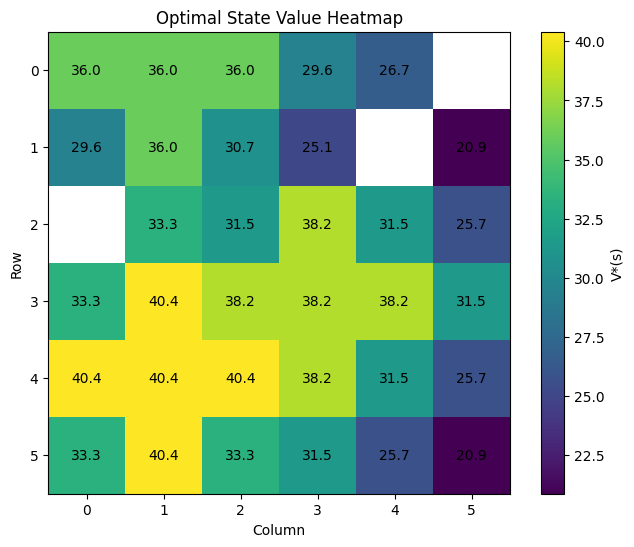

In [19]:
value_agent.visualize_value_function()

# DP Scalability Discussion

## Curse of Dimensionality

Dynamic Programming (DP) methods such as Value Iteration suffer from the **Curse of Dimensionality**, where the number of states grows exponentially as additional environment variables are added.

The state representation used in this project is:

\[
s = (position, battery\_level, rescue\_status)
\]

where:

- `position` represents the drone location in the grid,
- `battery_level` represents remaining battery capacity,
- `rescue_status` stores whether each rescue target has been rescued.

The total number of states can be approximated as:

\[
|S| = |Positions| \times |BatteryLevels| \times |RescueCombinations|
\]

As environment complexity increases, the state space grows rapidly, making Value Iteration computationally expensive.

---

## Effect of Increasing Grid Size

For a 5×5 or 6×6 grid, the state space remains manageable.

However, if the environment becomes 10×10:

- reachable positions increase significantly,
- more transitions must be evaluated,
- Bellman backups become much slower.

Example:

- 6×6 grid → ~33 reachable positions
- 10×10 grid → potentially ~100 reachable positions

This directly increases:

\[
O(|S| \times |A|)
\]

computational complexity per iteration.

---

## Effect of Adding More Rescue Targets

Each rescue target introduces a binary rescued/not-rescued status.

If there are:

- \(n\) rescue targets,

then rescue combinations become:

\[
2^n
\]

Examples:

| Rescue Targets | Rescue State Combinations |
|---|---|
| 2 | 4 |
| 3 | 8 |
| 5 | 32 |
| 10 | 1024 |

This exponential growth rapidly increases memory usage and convergence time.

---

## Effect of Dynamic Weather Conditions

If weather conditions become dynamic:

- wind direction,
- wind intensity,
- turbulence zones,

must also be represented in the state space.

An extended state representation could become:

\[
s=(position,battery,rescue\_status,weather)
\]

This further increases the dimensionality of the MDP.

Additionally, stochastic weather introduces non-deterministic transitions, making Bellman updates more difficult and slower to converge.

In this project, stochastic wind disturbances initially prevented Value Iteration convergence because transition outcomes changed during Bellman backups.

---

## Why DP Becomes Difficult

Dynamic Programming requires:

- explicit enumeration of all states,
- storage of value estimates for every state,
- repeated Bellman updates across the entire state space.

As state dimensionality increases:

- memory consumption grows rapidly,
- convergence becomes slower,
- runtime increases significantly.

This makes exact DP methods impractical for large-scale autonomous drone systems.

---

## How Deep RL Methods Could Help

Deep Reinforcement Learning (Deep RL) can address scalability limitations by approximating the value function using neural networks instead of explicit state tables.

Instead of storing:

\[
V(s)
\]

for every state individually, a neural network learns:

\[
V_\theta(s)
\]

which generalizes across similar states.

Deep RL methods such as:

- Deep Q-Networks (DQN),
- Deep Deterministic Policy Gradient (DDPG),
- Proximal Policy Optimization (PPO),

can handle:

- very large state spaces,
- stochastic environments,
- continuous state representations,
- dynamic weather conditions,
- high-dimensional sensory inputs.

They also avoid exhaustive state enumeration.

---

## Relation to Real-World Autonomous Drone Systems

Real-world autonomous drone systems operate in highly dynamic environments involving:

- changing weather,
- moving obstacles,
- uncertain GPS signals,
- battery degradation,
- real-time operational constraints.

Exact Dynamic Programming becomes infeasible because the state space is extremely large and continuously changing.

Modern autonomous drone systems therefore commonly use:

- Deep RL,
- Model Predictive Control (MPC),
- hierarchical planning,
- neural policy approximation,
- hybrid learning-based navigation systems.

These approaches provide better scalability and adaptability for real-world deployment.

# Conclusion

The assignment demonstrated how Dynamic Programming can solve
finite-state autonomous navigation problems. Value Iteration
successfully computed an optimal rescue strategy while balancing
battery management, rescue completion, and danger avoidance.

The experiment also highlighted the scalability limitations of
classical DP methods and motivated the use of Deep RL techniques
for large-scale autonomous systems.